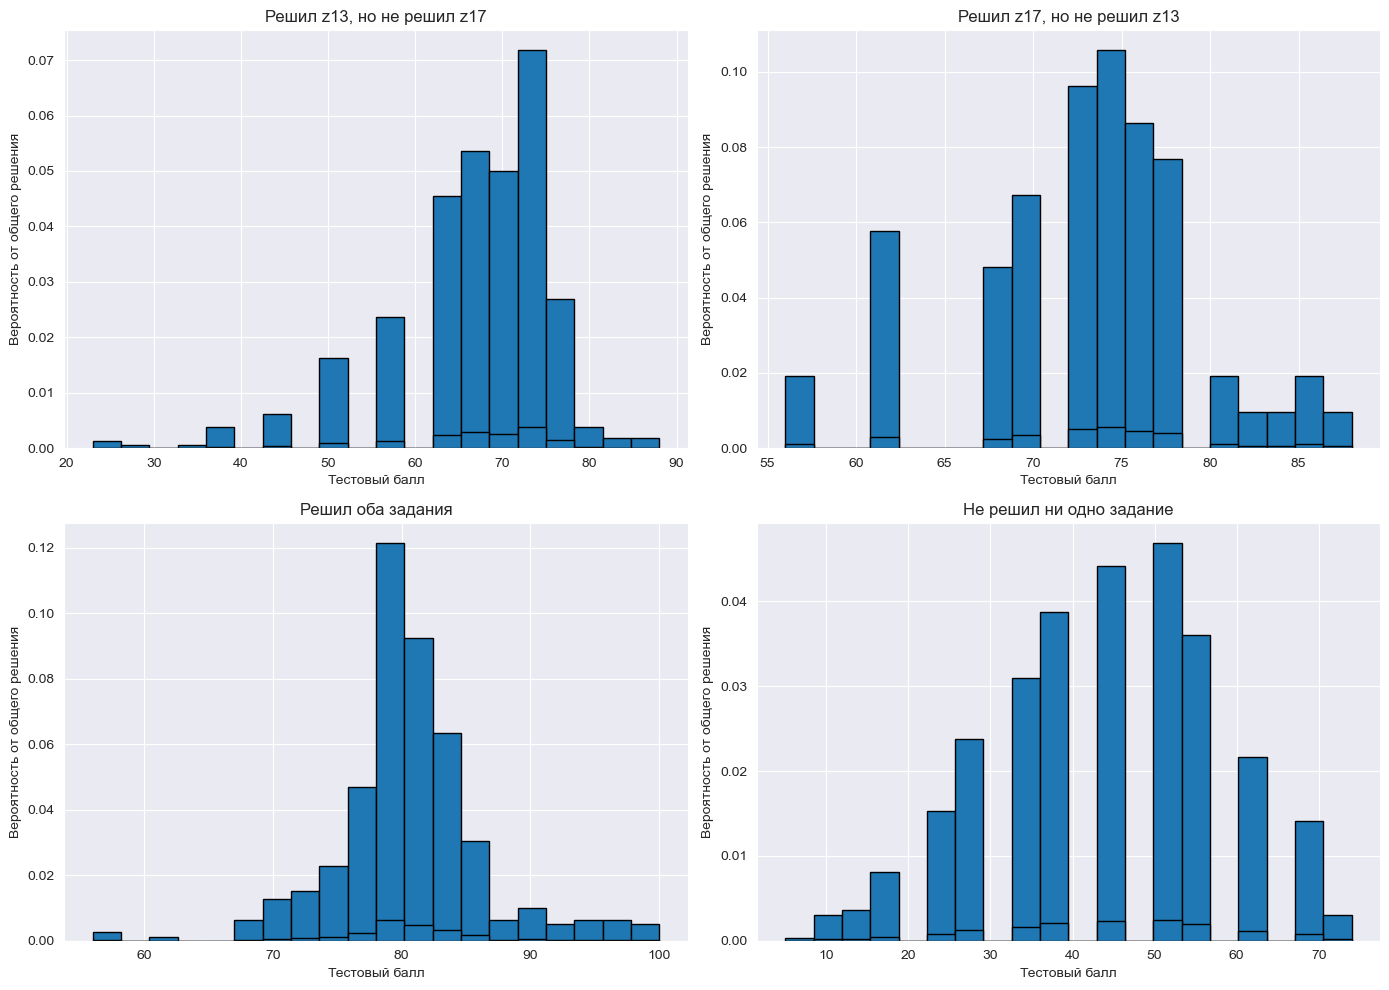

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

file_path = 'ege_2021.xlsx'
df = pd.read_excel(file_path)

z13 = df['z13']
z17 = df['z17']
total_scores = df['Тестовый балл']

group1 = df[(df['z13'] != 0) & (df['z17'] == 0)]
group2 = df[(df['z17'] != 0) & (df['z13'] == 0)]
group3 = df[(df['z13'] != 0) & (df['z17'] != 0)]
group4 = df[(df['z13'] == 0) & (df['z17'] == 0)]

total_count = len(df)

def plot_histogram(data, ax, title):
    counts, bins, patches = ax.hist(data['Тестовый балл'], bins=20, edgecolor='black', density=True)
    percentages = counts / total_count * 100
    ax.bar(bins[:-1], percentages, width=np.diff(bins), edgecolor='black', align='edge')
    ax.set_xlabel('Тестовый балл')
    ax.set_ylabel('Вероятность от общего решения')
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_histogram(group1, axes[0, 0], 'Решил z13, но не решил z17')
plot_histogram(group2, axes[0, 1], 'Решил z17, но не решил z13')
plot_histogram(group3, axes[1, 0], 'Решил оба задания')
plot_histogram(group4, axes[1, 1], 'Не решил ни одно задание')

plt.tight_layout()
plt.show()


In [56]:
# Уравнение линейной регрессии и коэффициенты для каждой группы
def regression_analysis(x, y):
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return slope, intercept, r_value, r_value**2, std_err

slope1, intercept1, r_value1, r_squared1, std_err1 = regression_analysis(group1['z13'], group1['Тестовый балл'])
slope2, intercept2, r_value2, r_squared2, std_err2 = regression_analysis(group2['z17'], group2['Тестовый балл'])
slope3, intercept3, r_value3, r_squared3, std_err3 = regression_analysis(group3['z13'], group3['Тестовый балл'])
slope4, intercept4, r_value4, r_squared4, std_err4 = regression_analysis(group4.index, group4['Тестовый балл'])

print(f"Группа 1: Решил z13, но не решил z17")
print(f"Уравнение линейной регрессии: y = {slope1:.2f}x + {intercept1:.2f}")
print(f"Коэффициент корреляции: {r_value1:.2f}")
print(f"Коэффициент детерминации: {r_squared1:.2f}")
print(f"Стандартная ошибка: {std_err1:.2f}\n")

print(f"Группа 2: Решил z17, но не решил z13")
print(f"Уравнение линейной регрессии: y = {slope2:.2f}x + {intercept2:.2f}")
print(f"Коэффициент корреляции: {r_value2:.2f}")
print(f"Коэффициент детерминации: {r_squared2:.2f}")
print(f"Стандартная ошибка: {std_err2:.2f}\n")

print(f"Группа 3: Решил оба задания")
print(f"Уравнение линейной регрессии: y = {slope3:.2f}x + {intercept3:.2f}")
print(f"Коэффициент корреляции: {r_value3:.2f}")
print(f"Коэффициент детерминации: {r_squared3:.2f}")
print(f"Стандартная ошибка: {std_err3:.2f}\n")

print(f"Группа 4: Не решил ни одно задание")
print(f"Уравнение линейной регрессии: y = {slope4:.2f}x + {intercept4:.2f}")
print(f"Коэффициент корреляции: {r_value4:.2f}")
print(f"Коэффициент детерминации: {r_squared4:.2f}")
print(f"Стандартная ошибка: {std_err4:.2f}\n")

mean_x1, mean_y1 = np.mean(group1['z13']), np.mean(group1['Тестовый балл'])
elasticity1 = slope1 * (mean_x1 / mean_y1)
beta_coefficient1 = slope1 * (np.std(group1['z13']) / np.std(group1['Тестовый балл']))

mean_x2, mean_y2 = np.mean(group2['z17']), np.mean(group2['Тестовый балл'])
elasticity2 = slope2 * (mean_x2 / mean_y2)
beta_coefficient2 = slope2 * (np.std(group2['z17']) / np.std(group2['Тестовый балл']))

mean_x3, mean_y3 = np.mean(group3['z13']), np.mean(group3['Тестовый балл'])
elasticity3 = slope3 * (mean_x3 / mean_y3)
beta_coefficient3 = slope3 * (np.std(group3['z13']) / np.std(group3['Тестовый балл']))

mean_y4 = np.mean(group4['Тестовый балл'])
elasticity4 = slope4 * (0 / mean_y4)  # group4['z13'] и group4['z17'] равны 0
beta_coefficient4 = 0  # не применимо, так как нет переменных z13 и z17

print(f"Группа 1: Коэффициент эластичности: {elasticity1:.2f}, Бета-коэффициент: {beta_coefficient1:.2f}")
print(f"Группа 2: Коэффициент эластичности: {elasticity2:.2f}, Бета-коэффициент: {beta_coefficient2:.2f}")
print(f"Группа 3: Коэффициент эластичности: {elasticity3:.2f}, Бета-коэффициент: {beta_coefficient3:.2f}")
print(f"Группа 4: Коэффициент эластичности: {elasticity4:.2f}, Бета-коэффициент: Не применимо")

Группа 1: Решил z13, но не решил z17
Уравнение линейной регрессии: y = 8.84x + 51.77
Коэффициент корреляции: 0.44
Коэффициент детерминации: 0.20
Стандартная ошибка: 0.81

Группа 2: Решил z17, но не решил z13
Уравнение линейной регрессии: y = 6.17x + 55.40
Коэффициент корреляции: 0.49
Коэффициент детерминации: 0.24
Стандартная ошибка: 1.40

Группа 3: Решил оба задания
Уравнение линейной регрессии: y = 4.42x + 72.41
Коэффициент корреляции: 0.26
Коэффициент детерминации: 0.07
Стандартная ошибка: 0.85

Группа 4: Не решил ни одно задание
Уравнение линейной регрессии: y = 0.00x + 42.28
Коэффициент корреляции: 0.06
Коэффициент детерминации: 0.00
Стандартная ошибка: 0.00

Группа 1: Коэффициент эластичности: 0.22, Бета-коэффициент: 0.44
Группа 2: Коэффициент эластичности: 0.24, Бета-коэффициент: 0.49
Группа 3: Коэффициент эластичности: 0.10, Бета-коэффициент: 0.26
Группа 4: Коэффициент эластичности: 0.00, Бета-коэффициент: Не применимо


Выводы:

  Группа 2, которая решила задание z17, но не решила z13, имеет наибольший коэффициент корреляции (0.49) и наибольший коэффициент детерминации (0.24), что может указывать на более сильную связь между решением задания z17 и тестовым баллом по сравнению с другими группами.

  Группа 3, которая решила оба задания, демонстрирует наименьший коэффициент детерминации (0.07), что может свидетельствовать о слабой предсказательной способности модели для этой группы.

  Коэффициенты эластичности показывают, насколько процентное изменение в переменной (z13 или z17) влияет на процентное изменение в тестовом балле. Например, группа 2 имеет коэффициент эластичности 0.24, что означает, что увеличение переменной z17 на 1 единицу связано с увеличением тестового балла на 0.24%.

In [61]:
import numpy as np
from scipy.stats import t

# Выборка значений для z13 и z17, исключая 0
z13_values = df[df['z13'] != 0]['z13']
z17_values = df[df['z17'] != 0]['z17']

# Параметры
alpha = 0.05  # Уровень значимости

# Выборочные средние и выборочные стандартные отклонения
mean_z13 = np.mean(z13_values) / 2 
mean_z17 = np.mean(z17_values) / 3
std_z13 = np.std(z13_values, ddof=1)
std_z17 = np.std(z17_values, ddof=1)

# Количество элементов в выборках
n_z13 = z13_values.size
n_z17 = z17_values.size

# Вычисление t-статистики для независимых выборок
t_statistic = (mean_z13 - mean_z17) / np.sqrt((std_z13**2 / n_z13) + (std_z17**2 / n_z17))

# Количество степеней свободы
df_1 = n_z13 + n_z17 - 2

# Критическое значение для двустороннего t-теста
t_critical = t.ppf(1 - alpha/2, df_1)

# p-значение для двустороннего t-теста
p_value = 2 * (1 - t.cdf(np.abs(t_statistic), df_1))

# Вывод результатов
print("a.")
print("Нулевая гипотеза H0: математические ожидания z13 и z17 равны")
print("Альтернативная гипотеза H1: математические ожидания z13 и z17 не равны")

print("\nb.")
print(f"Вероятность решения для группы z13: {mean_z13:.2f}")
print(f"Вероятность решения для группы z17: {mean_z17:.2f}")
print(f"Выборочное стандартное отклонение для группы z13: {std_z13:.2f}")
print(f"Выборочное стандартное отклонение для группы z17: {std_z17:.2f}")
print(f"t-статистика: {t_statistic:.4f}")
print(f"Критическое значение: ±{t_critical:.4f}")
print(f"p-значение: {p_value:.4f}")

if np.abs(t_statistic) > t_critical:
    print(f"Отклоняем нулевую гипотезу H0 на уровне значимости {alpha}")
else:
    print(f"Не отклоняем нулевую гипотезу H0 на уровне значимости {alpha}")


a.
Нулевая гипотеза H0: математические ожидания z13 и z17 равны
Альтернативная гипотеза H1: математические ожидания z13 и z17 не равны

b.
Вероятность решения для группы z13: 0.88
Вероятность решения для группы z17: 0.94
Выборочное стандартное отклонение для группы z13: 0.43
Выборочное стандартное отклонение для группы z17: 0.51
t-статистика: -2.1900
Критическое значение: ±1.9618
p-значение: 0.0287
Отклоняем нулевую гипотезу H0 на уровне значимости 0.05


Значение t-статистики: -36.96. Это значение показывает, насколько сильно отклоняется среднее значение между двумя группами (z13 и z17) от ожидаемого случайного различия, если нулевая гипотеза (равенство средних) была верна.

p-value: 0.0000. Это очень маленькое значение p-value, что означает, что вероятность получить такие или еще более экстремальные различия между средними значениями z13 и z17 при условии, что нулевая гипотеза верна (то есть средние равны), близка к нулю.

Вывод: Учитывая маленькое значение p-value (меньше выбранного уровня значимости), мы отвергаем нулевую гипотезу о равенстве математических ожиданий z13 и z17. Это означает, что существует статистически значимое различие между средними значениями этих двух переменных в вашем наборе данных.